 
# 文本生成案例——莎士比亚文集——LSTM

## 数据集加载

In [1]:
import tensorflow as tf
import os

# 获取当前工作目录下的 data 文件夹绝对路径
current_dir = os.getcwd()
target_dir = os.path.join(current_dir, 'data')

# get_file 的逻辑是：存储路径 = cache_dir / cache_subdir / filename
path_to_file = tf.keras.utils.get_file(
    'shakespeare.txt', 
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt',
    cache_dir=current_dir,    # 设置缓存根目录为当前目录
    cache_subdir='data'       # 设置子目录为 data
)

print(f"文件已保存至: {path_to_file}")

文件已保存至: d:\rozen_file\WangDao_PythonAI\Day18\data\shakespeare.txt


In [2]:
with open("./data/shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

# 构建字符级字典

# set(text): 将字符串 text 转换为一个集合（Set）。集合的特性是去重，所以这一步会去掉所有重复出现的字符，只保留唯一的字符
# list(...): 将集合转换回列表（List）
# sorted(...): 对列表进行排序
chars = sorted(list(set(text)))

# enumerate(chars):  返回enumerate(枚举)对象 (i, ch) 是 chars 中的每个字符及其索引
char2idx = {ch: i for i, ch in enumerate(chars)}  # 字符 -> 索引
idx2char = {i: ch for i, ch in enumerate(chars)}  # 索引 -> 字符

print(f"总共有 {len(chars)} 个不同的字符")

总共有 65 个不同的字符


In [3]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class TextDataset(Dataset):
    def __init__(self, text_ids, seq_len=101):
        self.text_ids = text_ids
        self.seq_len = seq_len
        self.num_seq = len(text_ids) // self.seq_len #样本的个数

    def __len__(self):
        return self.num_seq

    def __getitem__(self, idx):
        # 获取第idx个样本的输入和目标序列
        return self.text_ids[idx*self.seq_len:(idx+1)*self.seq_len]


text_ids = [char2idx[ch] for ch in text]  # 将文本转换为索引序列
dataset = TextDataset(text_ids, seq_len=101)  # 创建数据集


def collate_fn(batch):
    # batch shape: (batch_size, seq_len)
    batch = torch.tensor(batch, dtype=torch.long)
    # 前100个字符作为输入
    x = batch[:, :100]
    # 后100个字符作为label
    y = batch[:, 1:101]
    return x, y

dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)


In [4]:
for x, y in dataloader:
    print(x.shape, y.shape)
    break

torch.Size([64, 100]) torch.Size([64, 100])


## 搭建模型

In [5]:
import torch.nn as nn

class CharLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=1024, hidden_size=256, num_layers=1):
        super(CharLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, hidden=None):
        # x: (batch_size, seq_len)
        x = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        # LSTM返回 (output, (h_n, c_n))，其中h_n是隐藏状态，c_n是细胞状态
        out, hidden = self.lstm(x, hidden)  # out: (batch_size, seq_len, hidden_size)
        out = self.fc(out)  # (batch_size, seq_len, vocab_size)
        return out, hidden


vocab_size = len(char2idx)
model = CharLSTMModel(vocab_size)


In [6]:
# 简单的前向计算示例
# 假设有一个batch的数据x
x, y = next(iter(dataloader))
output, hidden = model(x)
print("output shape:", output.shape)  # 应为 (batch_size, seq_len, vocab_size)


output shape: torch.Size([64, 100, 65])


## 模型训练

In [7]:
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练参数
num_epochs = 10
train_losses = []

# 训练循环
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0  # 累计每个epoch的损失
    num_batches = 0   # 累计每个epoch的batch数量
    
    for batch_idx, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)  # y : (batch_size, seq_len)
        
        # 前向传播
        output, hidden = model(x)  # output: (batch_size, seq_len, vocab_size)
        
        # PyTorch 的 nn.CrossEntropyLoss 默认期望的输入格式如下：
        # - 预测值 (Input): 形状为 (N, C)，其中 N 是样本数，C 是类别数（即 vocab_size）。
        # - 目标值 (Target): 形状为 (N)，其中每个元素是 0 到 C-1 之间的整数。
        # 自然语言处理（NLP）或序列生成任务中，你的输出通常是三维的
        # 因此，需要将输出重塑为二维的 (batch_size * seq_len, vocab_size)
        # 同时，目标值也需要重塑为 (batch_size * seq_len,)

        # 将输出和目标重塑为 (batch_size * seq_len, vocab_size) 和 (batch_size * seq_len,)
        output = output.reshape(-1, output.shape[-1])
        y = y.reshape(-1)
        
        # 计算交叉逆熵损失
        loss = criterion(output, y)
        
        # 反向传播
        optimizer.zero_grad()  # 清空梯度
        loss.backward()       # 反向传播计算梯度
        optimizer.step()      # 更新模型参数
        
        # 累计每个batch的损失
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches  # 计算每个epoch的平均损失
    train_losses.append(avg_loss)  # 记录每个epoch的平均损失
    print(f'Epoch [{epoch+1}/{num_epochs}] 完成, 平均损失: {avg_loss:.4f}')

print('训练完成！')


Epoch [1/10] 完成, 平均损失: 2.1905
Epoch [2/10] 完成, 平均损失: 1.7818
Epoch [3/10] 完成, 平均损失: 1.6632
Epoch [4/10] 完成, 平均损失: 1.5929
Epoch [5/10] 完成, 平均损失: 1.5468
Epoch [6/10] 完成, 平均损失: 1.5135
Epoch [7/10] 完成, 平均损失: 1.4883
Epoch [8/10] 完成, 平均损失: 1.4680
Epoch [9/10] 完成, 平均损失: 1.4506
Epoch [10/10] 完成, 平均损失: 1.4361
训练完成！


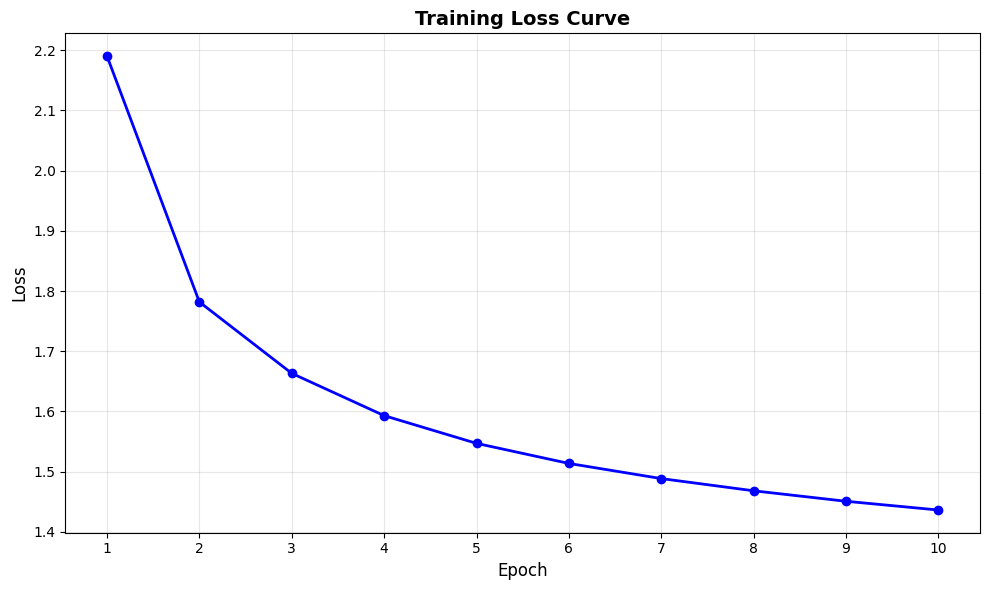

最终损失: 1.4361


In [8]:
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', linewidth=2, marker='o', markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, num_epochs + 1))
plt.tight_layout()
plt.show()

print(f'最终损失: {train_losses[-1]:.4f}')


In [9]:
from tqdm import tqdm  # 导入tqdm用于显示进度条
import torch.nn.functional as F

def generate_text(model, start_string, max_len=1000, temperature=1.0, stream=True):
    """
    Args:
        model: 训练好的模型
        start_string: 开始字符串
        max_len: 最大生成长度
        temperature: 温度参数，控制生成结果的多样性
        stream: 是否流式输出
    """
    # 将开始字符串转换为索引 shape(batch_size, seq_len)，要保证输入与训练时的数据shape一致
    input_eval = torch.Tensor([char2idx[char] for char in start_string]).to(dtype=torch.int64, device=device).reshape(1, -1) 
    hidden = None # 初始隐藏状态
    text_generated = [] #用来保存生成的文本
    model.eval()  # 设置为评估模式
    pbar = tqdm(range(max_len)) # 进度条
    print(start_string, end="")
    # no_grad是一个上下文管理器，用于指定在其中的代码块中不需要计算梯度。在这个区域内，不会记录梯度信息，用于在生成文本时不影响模型权重。
    with torch.no_grad():
        # 模型前向传播：将当前的输入（一开始是 start_string，后来是上一轮生成的单字符）和上一步的隐藏状态 hidden 喂给模型。
        # 模型输出预测的 logits（未归一化的得分）和更新后的 hidden。
        for i in pbar:
            # logits：模型预测的每个字符的概率分布
            logits, hidden = model(input_eval, hidden=hidden) #logits shape(batch_size,seq_len,vocab_size)
            # 温度采样，较高的温度会增加预测结果的多样性，较低的温度则更加保守。
            # 温度采样（Temperature Scaling）：除以 temperature 是控制生成文本多样性的关键。
            # - 当 temperature < 1：得分高的字符会被进一步放大，模型会生成更“保守”、“安全”的文本，但也容易陷入重复。
            # - 当 temperature > 1：得分差异被缩小，低概率的字符也有机会被选中，生成的文本更具创意和随机性。
            logits = logits[0, -1, :] / temperature
            # using multinomial to sampling
            probs = F.softmax(logits, dim=-1) #算为概率分布
            #根据模型预测的概率分布进行 “加权随机抽样” （概率大的被抽到的可能性更大）
            # .item()：从张量转换为普通数字
            idx = torch.multinomial(probs, 1).item()

            # 将本轮生成字母作为下轮开始字符
            input_eval = torch.Tensor([idx]).to(dtype=torch.int64, device=device).reshape(1, -1) #把idx转为tensor
            text_generated.append(idx)
            if stream:
                print(idx2char[idx], end="", flush=True)  # 流式输出生成文本
    return "".join([idx2char[i] for i in text_generated])


# load checkpoints
# model.load_state_dict(torch.load("checkpoints/text_generation/best.ckpt", map_location="cpu"))
start_string = "All:"
res = generate_text(model, start_string, max_len=1000, temperature=0.5, stream=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

All:
Make the prides a sun to me

  3%|▎         | 28/1000 [00:00<00:03, 275.68it/s]

, such some honour
Than be what he bodies from his country so.

GREMIO:
I was that in m

 12%|█▏        | 115/1000 [00:00<00:01, 620.82it/s]

...

 90%|████████▉ | 897/1000 [00:01<00:00, 865.68it/s]

bsee, stop in the way to me.

CAMILLO:
Have I am hungs that speak but be some could no 

 98%|█████████▊| 984/1000 [00:01<00:00, 862.58it/s]

more for the cou

100%|██████████| 1000/1000 [00:01<00:00, 813.45it/s]


In [10]:
# 查看生成结果
print('生成文本：')
print(res)

生成文本：

Make the prides a sun to me, such some honour
Than be what he bodies from his country so.

GREMIO:
I was that in my love,
The king of shall make a man with the proved,
Which with his tranious will do you have should
He speaks of the stand of the said of the part of your son
That you that he was not a sons at the sun
Be prove thy cannot be a good for the like a brother;
For she since to the earth with the damned,
And that seet a man and men and therefore.

CORIOLANUS:
And what you do the lands and that he would sweet heart
As he would not single and then, he is a man
that that was a pale a passing to the devils.

CLARENCE:
Then with the world to your service.

LUCENTIO:
Where as the bring my love.

CORIOLANUS:
He's mercy wish a hour looks of his dares.

GLOUCESTER:
What is a poor sorrow; and her good more thee.

DUKE VINCENTIO:
Why, and he is the traniter to prayer than
truth of my subsee, stop in the way to me.

CAMILLO:
Have I am hungs that speak but be some could no more for t